In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.559867251677275, 24.843493531106528)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.44it/s]


In [5]:
# x = dataset['observations']
# coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


# def normalize_dataset_coords(dataset_):
#     dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
#     dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
#     dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
#     return dataset

# def denormalize_dataset_coords(dataset_):
#     dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
#     dataset[..., 0] = ((dataset[..., 0] / 20) + 0.5) * (coord_0_max - coord_0_min) + coord_0_min
#     dataset[..., 1] = ((dataset[..., 1] / 20) + 0.5) * (coord_1_max - coord_1_min) + coord_1_min
#     return dataset

In [6]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001]



num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [7]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean) / dataset_std
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = dataset * dataset_std + dataset_mean
    else:
        dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)

In [8]:
# plt.scatter(dataset_trajectories[::10, 0], dataset_trajectories[::10, 1], c='gray')


# i = 8000
# plt.scatter(dataset_trajectories[i:i+TRAJECTORY_LEN, 0], dataset_trajectories[i:i+TRAJECTORY_LEN, 1])
# plt.scatter(dataset_goals[i:i+TRAJECTORY_LEN, 0], dataset_goals[i:i+TRAJECTORY_LEN, 1])

In [9]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [10]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [11]:
# def get_training_data(batch_size, trajectory_length=TRAJECTORY_LEN, num_anchors=200, timesteps=None):
        

#     if timesteps is not None:
#         batch_size = len(timesteps)
    
#     trajectories = []
#     actions = []
    
#     if timesteps is None:
#         timesteps = []
#         while len(trajectories) != batch_size:
#             timestep = random.randint(0, dataset_trajectories.shape[0] - trajectory_length)
#             if dataset_timeouts[timestep:timestep+trajectory_length].any():
#             # if dataset_terminals[timestep:timestep+trajectory_length].any() or dataset_timeouts[timestep:timestep+trajectory_length].any():
#                 pass
#             else:
#                 trajectories.append(dataset_trajectories[timestep:timestep+trajectory_length])
#                 actions.append(dataset_actions[timestep:timestep+trajectory_length])
#                 timesteps.append(timestep)
    
#     else:
#         for timestep in timesteps:
#             trajectories.append(dataset_trajectories[timestep:timestep+trajectory_length])
#             actions.append(dataset_actions[timestep:timestep+trajectory_length])
        
        
            
#     trajectories = torch.stack(trajectories)
#     actions = torch.stack(actions)
    
        
#     trajectories_idx_ = torch.arange(0, batch_size).unsqueeze(-1).long()
#     trajectories_idx = trajectories_idx_.repeat(1, num_anchors).reshape(-1)
#     states_idx = torch.linspace(0, trajectory_length-1, num_anchors).long().repeat(batch_size)

    
#     anchors = trajectories[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
#     actions = actions[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
    
    
#     return (anchors, actions), {'timesteps': timesteps}

In [12]:
def get_training_data(batch_size, num_anchors, num_states, trajectories_idx_=None):
    
    num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape
    
    if trajectories_idx_ is not None:
        batch_size = len(trajectories_idx_)
        
    if trajectories_idx_ is None: 
        trajectories_idx_ = torch.randint(0, num_trajectories, (batch_size,))      
        
    trajectories_idx_ = trajectories_idx_.unsqueeze(-1).long()    
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_anchors).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-1, num_anchors).long().repeat(batch_size)
    anchors = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
    anchors_actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_anchors, -1)
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_states).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-1, num_states).long().repeat(batch_size)
    states = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    
    
    return (anchors, anchors_actions), (states, actions), {'trajectories_idx': trajectories_idx_}

In [13]:
# (anchors, actions), (_, _), _ = get_training_data(
#     batch_size=16,
#     num_anchors=200,
#     num_states=500
# )

In [14]:
frenetwork = FRENetwork(state_dim=obs_dim, action_dim=8, num_layers=2, num_heads=2).to(device)
frenetwork.load_state_dict(torch.load('models/offline_agent_norm.pth'))

optimimizer = torch.optim.Adam(frenetwork.parameters(), lr=0.001)

losses = []
kl_losses = []

/tmp/ipykernel_7106/2378340175.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frenetwork.load_state_dict(torch.load('models/offline_agent_norm.pth'))


In [15]:
# (anchors, anchor_actions), (states, actions), info = get_training_data(
#     batch_size=256,
#     num_anchors=200,
#     num_states=500
# )

# i = 3
# plt.scatter(states[i, :, 0], states[i, :, 1])
# plt.scatter(anchors[i, :, 0], anchors[i, :, 1])

In [16]:
# for i in tqdm(range(5000)):
#     (anchors, anchor_actions), (states, actions), info = get_training_data(
#         batch_size=128,
#         num_anchors=200,
#         num_states=1000
#     )

#     anchors = anchors.to(device)
#     anchor_actions = anchor_actions.to(device)
#     states = states.to(device)
#     actions = actions.to(device)
    
#     w_mean, w_log_std = frenetwork.get_transformer_encoding(anchors, anchor_actions, pad_mask=None)

#     pred_actions = frenetwork.get_action_pred(w_mean, states)

#     # action_pred_loss = ((pred_actions - anchor_actions)**2).mean()
#     action_pred_loss = ((pred_actions - actions)**2).mean()
#     # action_pred_loss = (pred_actions - actions).pow(2).sum(-1).mean()


#     kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
#     loss = action_pred_loss + kl_loss * 0.01
            
            
#     optimimizer.zero_grad()
#     loss.backward()
#     optimimizer.step()

#     logs = {
#         'loss': loss.item(),
#         'action_pred_loss': action_pred_loss.item(),
#         'kl_loss': kl_loss  .item(),
#         'get_training_data:info': info
#     }
    
#     losses.append(logs['action_pred_loss'])
#     kl_losses.append(logs['kl_loss'])
    
#     if i % 10 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#         axs[0].plot(losses)
#         axs[0].set_xscale('log')
#         axs[1].plot(kl_losses)
#         plt.show()
        
#     # break

In [17]:
num_trajectories = dataset_trajectories.shape[0]
batch_size = 512
indicies = torch.arange(0, num_trajectories, dtype=torch.long)

z_list = []

for i in tqdm(range(0, num_trajectories, batch_size)):
    traj_idx = indicies[i:i+batch_size]
    
    (anchors, anchor_actions), _, info = get_training_data(
        batch_size=-1,
        num_anchors=200,
        num_states=1,
        trajectories_idx_=traj_idx
    )
    

    anchors, anchor_actions = anchors.to(device), anchor_actions.to(device)
    with torch.no_grad():
        frenetwork.eval()
        z, _ = frenetwork.get_transformer_encoding(anchors, anchor_actions, pad_mask=None)
    
    
    z_list.append(z)
    
zs = torch.concat(z_list).cpu()

pre_computed_zs = zs

  0%|          | 0/2 [00:00<?, ?it/s]/home/nazim/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 2/2 [00:00<00:00,  3.85it/s]


In [18]:
# torch.save(frenetwork.state_dict(), 'models/offline_agent_norm.pth')

In [19]:
def reset_to_state(env, state):
    env.sim.reset()
    qpos = env.init_qpos
    qpos[:] = np.array(state[:15]).astype(env.observation_space.dtype)
    qvel = env.init_qvel
    qvel[:] = np.array(state[15:]).astype(env.observation_space.dtype)
    
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

/home/nazim/.local/lib/python3.10/site-packages/gym/utils/seeding.py:38: DeprecationWarning: WARN: Function `rng.randn(*size)` is marked as deprecated and will be removed in the future. Please use `rng.standard_normal(size)` instead.
  deprecation(


Target Goal:  (32.6375714395028, 24.801279900533302)
1


100%|██████████| 2000/2000 [00:01<00:00, 1240.29it/s]


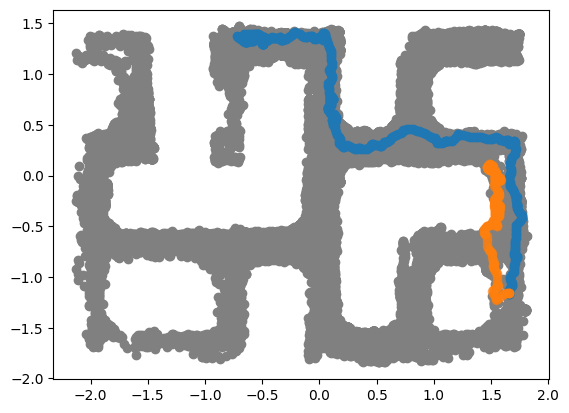

In [24]:
trajectory_idx = 1


state = env.reset()
# location = dataset_trajectories[0, :2].tolist()
location = dataset_trajectories[random.randint(0, len(dataset_trajectories)-1), :2].tolist()
location = np.array(env.unwrapped._wrapped_env._get_reset_location())
location = denormalize_dataset_coords(dataset_trajectories[trajectory_idx, 0, :].cpu())[..., :2]
state = reset_to_location(env, location)
# state = reset_to_state(env, denormalize_dataset_coords(dataset_trajectories[trajectory_idx, 0].cpu()))
state = normalize_dataset_coords(state)[..., :STATE_DIM]

# print(state[:2])

# eps = 1
# cond = (dataset_trajectories[:, 0] < state[0]+eps) & (dataset_trajectories[:, 0] > state[0]-eps) & (dataset_trajectories[:, 1] < state[1]+eps) & (dataset_trajectories[:, 1] > state[1]-eps)
# cond = (np.linalg.norm(dataset_trajectories[:, :2] - state[:2], ord=2, axis=1) < 1.)
# cond = (np.linalg.norm(dataset_trajectories[:, 0, :2] - state[:2], ord=2, axis=1) < 1.)

# print('possible start states:', cond.sum())

# valid_idx = np.nonzero(cond)[0]

# print('valid start states:', len(valid_idx))
# trajectory_idx = valid_idx[random.randint(0, len(valid_idx)-1)]
print(trajectory_idx)


(anchors, actions), _, info = get_training_data(batch_size=-1, num_anchors=200, num_states=500, trajectories_idx_=torch.tensor([trajectory_idx]))
anchors = anchors.to(device)
actions = actions.to(device)

w, _ = frenetwork.get_transformer_encoding(anchors, actions, pad_mask=None)




produced_trajectory = []

for _ in tqdm(range(2000)):
    tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
    
    with torch.no_grad():
        pred_action = frenetwork.get_action_pred(w, tensor_state).cpu()
        action = pred_action[0, 0]
        action = np.array(action)
        
    new_state, _, _, _ = env.step(action)

    
    produced_trajectory.append(state)

    state = new_state
    state = normalize_dataset_coords(state)[..., :STATE_DIM]
    
    
produced_trajectory = np.stack(produced_trajectory)



plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')


x = dataset_trajectories[trajectory_idx]
# print(x.any())
plt.scatter(x[:, 0], x[:, 1])
# plt.scatter(anchors[0, ::5, 0].cpu(), anchors[0, ::5, 1].cpu(), c='red')
plt.scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], alpha=0.5)

---
# Agent Evaluation:

In [20]:
def iou_similarity(traj1, traj2, grid_size=2):
    traj1 = (np.array(traj1[..., :2]) / grid_size).astype(int)
    traj2 = (np.array(traj2[..., :2]) / grid_size).astype(int)

    set1 = set(map(tuple, traj1))
    set2 = set(map(tuple, traj2))

    intersection = len(set1 & set2)
    union = len(set1 | set2)

    return intersection / union if union > 0 else 0.0

In [21]:
(eval_anchors, eval_actions), _, info = get_training_data(batch_size=-1, num_anchors=200, num_states=500, trajectories_idx_=torch.arange(0, 100))
eval_anchors = eval_anchors.to(device)
eval_actions = eval_actions.to(device)

In [23]:
all_produced_trajectories = []

for eval_i in tqdm(range(100)):

    for _ in range(5):

        state = env.reset()
        # location = dataset_trajectories[0, :2].tolist()
        location = np.array(denormalize_dataset_coords(eval_anchors[eval_i, 0, :].cpu()))[..., :2]
        state = reset_to_location(env, location)
        # state = reset_to_state(env, denormalize_dataset_coords(dataset_trajectories[trajectory_idx, 0].cpu()))
        state = normalize_dataset_coords(state)[..., :STATE_DIM]


        w, _ = frenetwork.get_transformer_encoding(eval_anchors[[eval_i]], eval_actions[[eval_i]], pad_mask=None)




        produced_trajectory = []

        for __ in range(1001):
            tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
            
            with torch.no_grad():
                pred_action = frenetwork.get_action_pred(w, tensor_state).cpu()
                action = pred_action[0, 0]
                action = np.array(action)
                
            new_state, _, _, _ = env.step(action)

            
            produced_trajectory.append(state)

            state = new_state
            state = normalize_dataset_coords(state)[..., :STATE_DIM]
            
            
        produced_trajectory = np.stack(produced_trajectory)
        all_produced_trajectories.append(produced_trajectory)

    clear_output(True)
    
all_produced_trajectories = np.array(all_produced_trajectories)

  6%|▌         | 6/100 [00:23<06:06,  3.89s/it]

Target Goal:  (32.425810064969234, 25.00865316924184)


  6%|▌         | 6/100 [00:23<06:15,  4.00s/it]


KeyboardInterrupt: 

In [34]:
# np.save('models/vae_trajectories', all_produced_trajectories)

In [35]:
sims = []

for eval_i in tqdm(range(100)):
    for j in range(5):
        sim = iou_similarity(torch.tensor(all_produced_trajectories[eval_i*5 + j]).cpu(), dataset_trajectories[eval_i].cpu()) 
        sims.append(sim)

sims_mean = np.array(sims).reshape(100, 5).mean(-1)
sims_std = np.array(sims).reshape(100, 5).std(-1)

100%|██████████| 100/100 [00:00<00:00, 209.42it/s]


IndexError: list index out of range

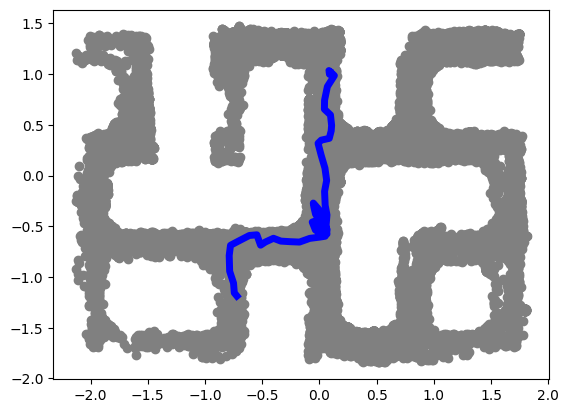

In [74]:
# i = sims_mean.argsort()[-5]
i = 3

plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

_ = plt.plot(eval_anchors[i, :, 0].cpu().flatten(), eval_anchors[i, :, 1].cpu().flatten(), linewidth=5, c='blue', alpha=1)

for j in range(i*5, (i+1)*5):
    sim = iou_similarity(torch.tensor(all_produced_trajectories[j]).cpu(), dataset_trajectories[i].cpu()) 
    _ = plt.plot(all_produced_trajectories[j, ..., 0].flatten(), all_produced_trajectories[j, ..., 1].flatten(), linewidth=2, alpha=1, label=f'{sim:.2f}')
plt.legend()

In [37]:
sims_mean.mean(), sims_mean.std()

(0.6682635138899776, 0.23306769811846217)

---
# Random Reward Generator:

In [22]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 8
MAX_NUM_ANCHORS = 8

In [23]:

class RNDModule(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self, state_dim):
        self.current = RNDModule(state_dim).to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule(state_dim).to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w

In [24]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [90]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: RewardGeneratorTransformer, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((Z_DIM,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((Z_DIM,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.new_actions_buffer = None
        self.new_zs_buffer = None
        
        self.states_buffer = None
        
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = Z_DIM
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
        self.resampling_weights = None
        
        self.pre_computed_zs = None

    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, num_intermediate_anchors=10, from_new_states=False, trajectories_idx_=None,
                          anchors_from_same_trajectory=True):
        assert min_num_anchors <= max_num_anchors <= num_states

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        buffer = dataset_trajectories[..., :].reshape(-1, obs_dim)
        
        num_states = max_num_anchors

        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        idx = self.get_importance_sampling_indices(batch_size*max_num_anchors,)
        # anchors = buffer[idx, :2]
        anchors = buffer[idx, :]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, num_states), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        # rewards[reward_mask] = torch.rand(max_num_anchors*batch_size).reshape(-1)
        # candidates = torch.tensor([0.01, 0.01, 0.01, 0.01, 0.25, 0.25, 0.25, 0.5, 0.5, 1.])
        # candidates = torch.tensor([0.0, 0.25, 0.5, 0.75])
        # candidates = torch.tensor([-1, -0.5, 0.0, 0.5])
        candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        # rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (max_num_anchors*batch_size,))]
        anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        # anchors_rewards[:, 0] = 1.
            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors[..., FEATURES_TO_CONSIDER].float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        # vecs = torch.ones_like(vecs)
        # vecs[:, :2] = True
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False, non_anchor_coef=1, anchors_from_same_trajectory=True):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
        # reward_pred_loss += ((inter_rewards_pred - info['intermediate_rewards'].to(device))**2).mean()
        # print(info['intermediate_anchors'].shape, info['intermediate_rewards'].shape, all_states.shape)
        # reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred[ is_anchor] - rewards[ is_anchor])**2).mean() + \
                        #    ((rewards_pred[~is_anchor] - rewards[~is_anchor])**2).mean() * non_anchor_coef
        # reward_pred_loss = ((rewards_pred - anchors_rewards)**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, anchors_from_same_trajectory=True, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            from_new_states=True,
            num_states=max_num_anchors+1,
            anchors_from_same_trajectory=anchors_from_same_trajectory
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.0)
        
        assert mask.shape == (batch_size, len(FEATURES_TO_CONSIDER))
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
            
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices

In [91]:
num_anchors = 16

rg_model = RewardGeneratorTransformer(obs_len=len(FEATURES_TO_CONSIDER))
# rg_model.load_state_dict(torch.load('models/offline_reward_generator.pth'))
# rg_model.load_state_dict(torch.load('models/offline_reward_generator_with_mask.pth'))


reward_generator_masked = RewardGenerator(
    obs_dim=len(FEATURES_TO_CONSIDER),
    fre_network=rg_model,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)

resampler = RNDResampling(state_dim=2)
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=1000)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.2)
reward_generator_masked.resampling_weights = resampling_weights


vae_loss, vae_kl_loss = [], []

100%|██████████| 1000/1000 [00:00<00:00, 1419.78it/s]


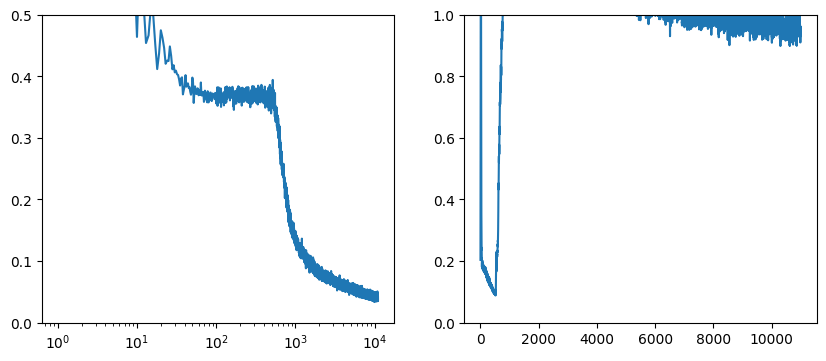

KeyboardInterrupt: 

In [92]:
print('VAE training...')
for step in tqdm(range(100_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator_masked.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
        from_new_states=True,
        num_states=MAX_NUM_ANCHORS+1,
        non_anchor_coef=0.0,
        anchors_from_same_trajectory=False
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        axs[0].set_xscale('log')
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
        
    # break


In [28]:
# torch.save(rg_model.state_dict(), 'models/offline_reward_generator.pth')

In [81]:
rg_model = RewardGeneratorTransformer(obs_len=len(FEATURES_TO_CONSIDER))
reward_generator_2 = RewardGenerator(
    obs_dim=len(FEATURES_TO_CONSIDER),
    fre_network=rg_model,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)
reward_generator_2.resampling_weights = resampling_weights


vae_loss_better, vae_kl_loss_better = [], []

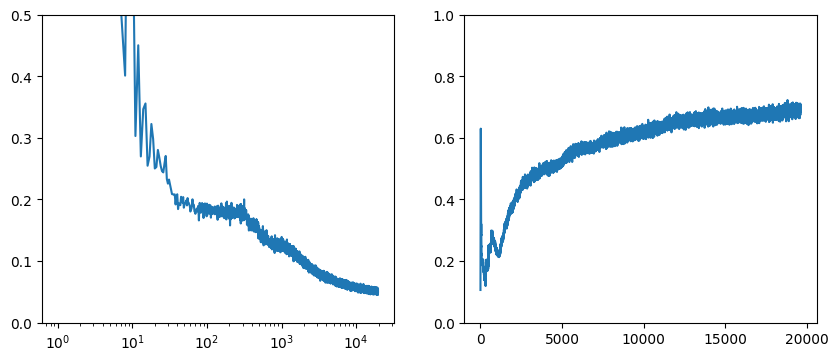

KeyboardInterrupt: 

In [85]:
num_anchors_not_masked = 64

print('Better VAE training...')
for step in tqdm(range(50_000), desc='VAE training', leave=False):
    
    # vae_loss_dict = reward_generator_masked.train_step_VAE(
        
    reward_generator_2.fre_network.train()
    
    batch_size = 256
    (anchors, _, pad_mask), _ = reward_generator_2.get_training_data(
        batch_size=batch_size, 
        min_num_anchors=num_anchors_not_masked, 
        max_num_anchors=num_anchors_not_masked,
        num_states=num_anchors_not_masked+1,
        from_new_states=False,
        anchors_from_same_trajectory=False
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)
    
    # Get rewards from the masked reward generator (to encourage simpler reward functions)
    with torch.no_grad():
        mask = reward_generator_masked.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        # mask = torch.zeros_like(mask)
        # mask[..., [0, 1]] = 1.
        w, _ = reward_generator_masked.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, anchors_from_same_trajectory=False, mask=mask)
        mask = mask.unsqueeze(1).repeat(1, num_anchors_not_masked, 1)
        mask = mask.to(device)
        x = anchors * mask
        anchors_rewards = reward_generator_masked.fre_network.get_reward_pred(w, x)
    
    
    w_mean, w_log_std = reward_generator_2.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    
    rewards_pred = reward_generator_2.fre_network.get_reward_pred(w, anchors)
    reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
    
    kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
    loss = reward_pred_loss + kl_loss * 0.01
    
    
    reward_generator_2.optimimizer.zero_grad()
    loss.backward()
    reward_generator_2.optimimizer.step()
    
        
    vae_loss_better.append(loss.item())
    vae_kl_loss_better.append(kl_loss.item())   
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss_better)
        axs[0].set_xscale('log')
        axs[0].set_ylim([0, 0.5])
        axs[1].plot(vae_kl_loss_better)
        axs[1].set_ylim([0, 1])
        plt.show()
        
    # break


In [47]:

def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, mask=None, trajectories=None, select_max_trajectory=False,
                                       mode='', plot_ax=None):
    # eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    # dataset_trajectories[:, 0].min(), dataset_trajectories[:, 0].max(), dataset_trajectories[:, 1].min(), dataset_trajectories[:, 1].max()

    s = 100
    x1_vals = np.linspace(dataset_trajectories[..., 0].min(), dataset_trajectories[..., 0].max(), s)
    x2_vals = np.linspace(dataset_trajectories[..., 1].min(), dataset_trajectories[..., 1].max(), s)

    # x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
    # x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

    # x1_vals = np.linspace(-0.3, 0.3, s)
    # x1_vals = np.round((x1_vals + 0.3) / 0.6 * 32)
    # x2_vals = np.linspace(-0.3, 0.3, s)
    # x2_vals = np.round((x2_vals + 0.3) / 0.6 * 32)



    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    # state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
    # state = torch.zeros((s*s, 2), dtype=torch.float32)
    # state[:, :2] = torch.tensor(state_x12)
    # state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
    # state = dataset_trajectories[200:300, :1000:10].reshape(-1, obs_dim)
    state = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    if mode == 'pos':
        state[..., 2:] = 0.
    if mode == 'vel':
        state[..., :15] = 0.
        state[..., 17:] = 0.
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()
    
    
    if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
        anchors_rewards = anchors_rewards * 0.5 + 0.5
        anchors_rewards = anchors_rewards.clip(0, 1)
        anchors_rewards = anchors_rewards * 20
        anchors_rewards = anchors_rewards + 0.1
                
        anchors = np.where(~pad_mask[..., None], anchors, None)
        anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
        
        

    for i in range(len(eval_z)):
        
        
        
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            x = state[..., FEATURES_TO_CONSIDER]
            if mask is not None:
                x = x * mask[i].unsqueeze(0).repeat(state.shape[0], 1).to(device)
            # x = torch.zeros_like(x)
            r = reward_generator.get_reward(x, zi).cpu()
        
        if plot_ax is not None:
            i = plot_ax
        
        axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.7, s=20, vmin=-1, vmax=1)
        # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
        # axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), shading='gouraud', alpha=1, vmin=-1, vmax=1)
        # axs[i].contourf(X1, X2, r.reshape(X1.shape), levels=20, alpha=1, vmin=0.1, vmax=1.0)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
        # axs[i].scatter(anchors[i, -1, 0].cpu(), anchors[i, -1, 1].cpu(), c=anchors_rewards[i, -1, 0],  edgecolors='red', vmin=0, vmax=1)
        # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='red', s=anchors_rewards[i, 0, 0].reshape(-1).cpu()*100)
        # axs[i].scatter(info['get_training_data:info']['base_anchors'][i, -1, 0].cpu(), info['get_training_data:info']['base_anchors'][i, -1, 1].cpu(), c='red', s=anchors_rewards[i, -1, 0].reshape(-1).cpu()*10)
        
        if trajectories is not None:
            if select_max_trajectory:
                # j = np.argmax([trajectories[j][0]['rewards'][TEMP_EPISODE_LENGTH*i:TEMP_EPISODE_LENGTH*(i+1)][-10:].mean() for j in range(len(trajectories))])
                max_j = np.argmax([trajectories[j][0]['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)].sum() for j in range(len(trajectories))])
                # trajectories = [trajectories[j]]
                
            for j in range(len(trajectories)):
                if select_max_trajectory:
                    j = max_j
                    
                trajectory, _ = trajectories[j]
                coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
                r_mean = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
                axs[i].scatter(coords[:, 0], coords[:, 1], s=10, c='black')
                
                axs[i].set_xlabel("X-Coordinates")
                axs[i].set_xlabel(f"{r_mean}")
                axs[i].set_ylabel("Y-Coordinates")
                
                if select_max_trajectory:
                    break
        
        # add_largest_maze_walls(axs[i])
        
        r_argmax = state[r.argmax(), :2].cpu()
        # axs[i].scatter(r_argmax[0].cpu(), r_argmax[1].cpu(), c='green', s=10)

    return fig, axs
    # plt.show()

In [1]:
eval_num_envs = 4

mask = reward_generator_masked.generate_boolean_mask(eval_num_envs, len(FEATURES_TO_CONSIDER), p=1.0)
mask = torch.zeros_like(mask)
mask[..., [0, 1, 15, 16]] = 1.
with torch.no_grad():
    w, _ = reward_generator_masked.get_z_from_random_anchors(eval_num_envs, min_num_anchors=16, max_num_anchors=16, anchors_from_same_trajectory=False, mask=mask)
    
fig, axs = visualize_rewards_and_trajectories(w, reward_generator_masked, mask=mask)

NameError: name 'reward_generator_masked' is not defined

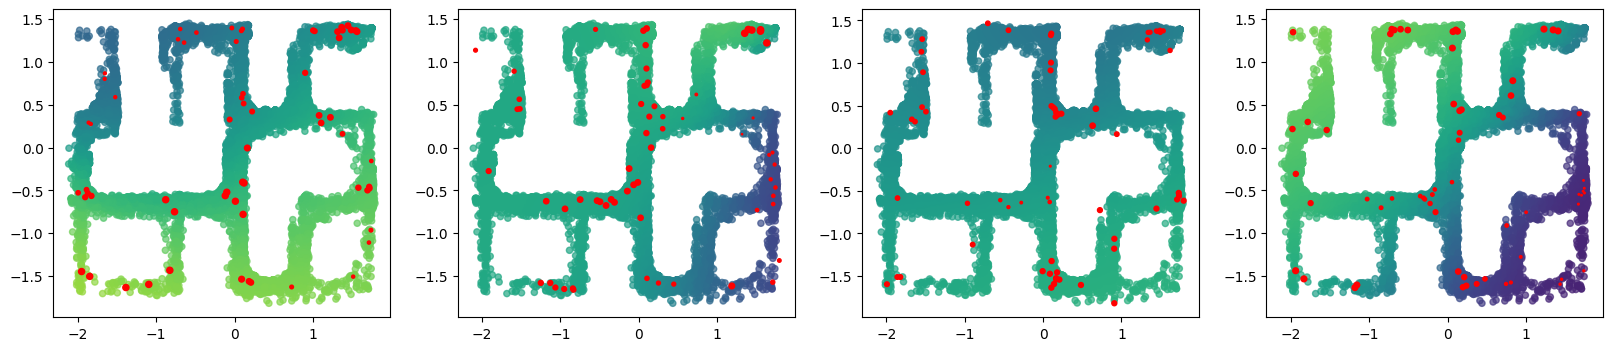

In [87]:
(anchors, _, pad_mask), _ = reward_generator_2.get_training_data(
    batch_size=eval_num_envs, 
    min_num_anchors=64, 
    max_num_anchors=64,
    num_states=64+1,
    from_new_states=False,
    anchors_from_same_trajectory=False
)
anchors = anchors.to(device)
pad_mask = pad_mask.to(device)

# Get rewards from the masked reward generator (to encourage simpler reward functions)
with torch.no_grad():
    mask_ = mask.clone()
    x = anchors * mask.unsqueeze(1).repeat(1, 64, 1).to(device)
    anchors_rewards = reward_generator_masked.fre_network.get_reward_pred(w, x)


w_mean, _ = reward_generator_2.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)

fig, axs = visualize_rewards_and_trajectories(w_mean, reward_generator_2, anchors.cpu(), anchors_rewards.cpu(), pad_mask.cpu(), mask=mask_.cpu())

# Reward alignement:

In [62]:
import matplotlib.patches as patches


STATE_SCALE = 8

def add_largest_maze_walls(ax):
    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * STATE_SCALE

    height, width = 10, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size
    # torso_x, torso_y = 0, 0

    # Get current axes
    # ax = plt.gca()

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        
        w = w * 1.2
        y = y * 1.2
        
        rect = patches.Rectangle((x-0.17, y+0.5), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
    # rect = patches.Rectangle(
    #     (-torso_x - block_size, -torso_y - block_size), 
    #     block_size*width*2, block_size*height*2, 
    #     linewidth=2, edgecolor='black', facecolor='none'
    # )
    # ax.add_patch(rect)


    # plt.axis('equal')
    # plt.xlim([-torso_x - block_size, -torso_x - block_size + block_size*width*2])
    # plt.ylim([-torso_y - block_size, -torso_y - block_size + block_size*height*2])
    # plt.show()

In [63]:
class RewardTrajectoryAlignement(nn.Module):
    def __init__(self, state_dim, z_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + z_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, z_dim),
        )
        
    def forward(self, state, z_dim):
        x = torch.concat([state, z_dim], dim=-1)
        return self.model(x)

In [64]:
dataset_trajectories_cuda = dataset_trajectories.to(device)

In [65]:
alg_batch_size = 64
num_considered_steps = 10
num_trajectories, len_trajectory, obs_len = dataset_trajectories.shape

In [66]:
R2T_model = RewardTrajectoryAlignement(state_dim=len(FEATURES_TO_CONSIDER), z_dim=128).to(device)
R2T_optimizer = torch.optim.Adam(R2T_model.parameters(), lr=0.001)
R2T_losses = []

In [67]:
# def get_best_trajectory(start_states, reward_w):
    
#     best_traj_w = []
#     best_traj_idx = []

#     for i in range(reward_w.shape[0]):
        
#         # Only keep the trajectories that start with `start_states`
#         cond = (torch.norm(dataset_trajectories[:, 0, :2] - start_states[i], p=2, dim=1) < 1.)
        
#         # For more efficiency no need to calculate the reward of all the states, we take only N well-spread states
#         state_idx = torch.linspace(0, len_trajectory-1, num_considered_steps).long()
#         # x = dataset_trajectories[cond][:, state_idx, :2]
#         x = dataset_trajectories[cond][:, -num_considered_steps*4::4, :2]
        
#         num_filtered_trajectories, _, _ = x.shape
        
#         x = x.reshape(-1, 2).to(device)
#         w = reward_w[[i]].repeat(x.shape[0], 1)

#         with torch.no_grad():
#             print(x.shape)
#             r = reward_generator_2.get_reward(x, w).reshape(num_filtered_trajectories, num_considered_steps)
            
#             # Calculate the sum of all reward over the trajectories
#             cumm_r = r.sum(-1)

#         # Find the index of the best trajectory in the set of valid trajectories
#         relative_trag_max_idx = cumm_r.argmax().item()
        
#         # Find the index of the best trajectory in the of all trajectories
#         trag_max_idx = torch.arange(0, num_trajectories)[cond][relative_trag_max_idx]
        
#         best_traj_idx.append(torch.arange(0, num_trajectories)[cond][cumm_r.argsort(descending=True).cpu()])
#         best_traj_w.append(pre_computed_zs[trag_max_idx])
        
#     # The representations of the best trajectories:
#     best_traj_w = torch.stack(best_traj_w).to(device)
    
#     return best_traj_w, {'best_traj_idx': best_traj_idx}

In [68]:
def get_best_trajectory(start_states, reward_w, num_considered_steps=100):
    
    best_traj_w = []
    best_traj_idx = []

    for i in range(reward_w.shape[0]):
        
        start_states = start_states.to(device)
        
        cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - start_states[i, :2].unsqueeze(0), p=2, dim=2) < 0.5)

        valid_trajectories_bool = cond.any(dim=1) # True if the trajectory contains the start_state, otherwise False
        valid_trajectories_idx = torch.nonzero(valid_trajectories_bool).flatten() # The indicies of the trajectories containing the start_state
        valid_start_states_idx = cond[valid_trajectories_bool].long().argmax(dim=1) # The index of the start_state in each trajectory (the start of the sub-trajectory)
        # print(valid_trajectories_idx)
        # print(valid_start_states_idx)
        # break

        # The index of the states from each sub-trajectory        
        valid_start_states_idx = valid_start_states_idx.unsqueeze(1)  # (N, 1)
        step_fractions = torch.linspace(0, 1, num_considered_steps, device=valid_start_states_idx.device)  # (S,)
        state_idx = valid_start_states_idx + (TRAJECTORY_LEN - 1 - valid_start_states_idx) * step_fractions  # (N, S)
        state_idx = state_idx.long()  # Optional: use .floor() or .ceil() depending on behavior

        
        # x = torch.stack([dataset_trajectories_cuda[valid_trajectories_idx[i], state_idx[i], :2] for i in range(len(valid_trajectories_idx))])
        # x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :2]
        x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx][..., FEATURES_TO_CONSIDER]
        
        num_filtered_trajectories, _, obs_dim = x.shape
        
        x = x.reshape(-1, obs_dim).to(device)
        w = reward_w[[i]].repeat(x.shape[0], 1)

        with torch.no_grad():
            r = reward_generator_2.get_reward(x, w).reshape(num_filtered_trajectories, num_considered_steps)
            
            # Calculate the sum of all reward over the trajectories
            cumm_r = r.sum(-1)

        # Find the index of the best trajectory in the set of valid trajectories
        relative_traj_max_idx = cumm_r.argmax().item()
        
        # Find the index of the best trajectory in the of all trajectories
        traj_max_idx = torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][relative_traj_max_idx]
        
        best_traj_idx.append(torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][cumm_r.argsort(descending=True).cpu()])
        best_traj_w.append(pre_computed_zs[traj_max_idx])
    
    # The representations of the best trajectories:
    best_traj_w = torch.stack(best_traj_w).to(device)
    
    return best_traj_w, {'best_traj_idx': best_traj_idx}

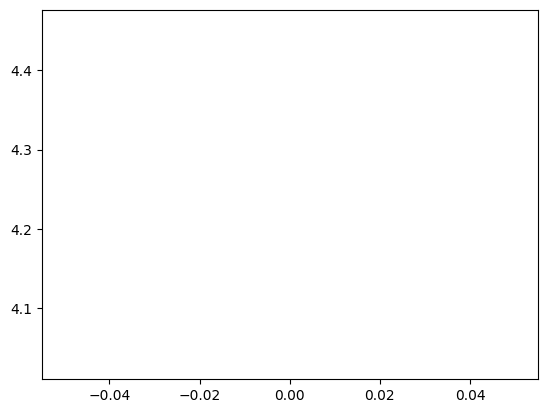

  0%|          | 0/10000 [00:00<?, ?it/s]


In [69]:
for training_step in tqdm(range(10000)):

    # Get random starting states:
    start_states = dataset_trajectories[
        torch.randint(0, dataset_trajectories.shape[0], (alg_batch_size,)), 
        torch.randint(0, dataset_trajectories.shape[1], (alg_batch_size,)), 
        :
    ][..., FEATURES_TO_CONSIDER]

    # Get random reward functions:
    reward_w, info = reward_generator_2.get_z_from_random_anchors(batch_size=alg_batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)


    # Collect the best trajectories that start from `start_states` and maximize `reward_w`:

    best_traj_w, get_best_trajectory_info = get_best_trajectory(start_states, reward_w)

    # break


    start_states = start_states.to(device)
    reward_w = reward_w.to(device)

    predcited_best_traj_w = R2T_model(start_states, reward_w)

    
    # break
    loss = (predcited_best_traj_w - best_traj_w).pow(2).sum(-1).mean()


    R2T_optimizer.zero_grad()
    loss.backward()
    R2T_optimizer.step()

    R2T_losses.append(loss.item())
    
    if training_step % 10 == 0:
        clear_output(True)
        plt.plot(R2T_losses)
        plt.show()
        
    break

In [70]:
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

# plt.scatter(dataset_trajectories[cond][:, 0], dataset_trajectories[cond][:, 1])
# plt.scatter(start_states[i, 0], start_states[i, 1])

In [71]:
# torch.save(R2T_model.state_dict(), 'models/offline_R2T_model.pth')

In [72]:
# best_traj_idx = get_best_trajectory_info['best_traj_idx']

# fig, axs = visualize_rewards_and_trajectories(reward_w, reward_generator_2)

# for i in range(len(best_traj_idx)):

#     trajectory_idx = best_traj_idx[i][0]

#     # axs[i].scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')


#     axs[i].scatter(dataset_trajectories[trajectory_idx, :, 0], dataset_trajectories[trajectory_idx, :, 1], c='blue')

#     # i = 4
#     # axs[i].scatter(dataset_trajectories[cond][i, :, 0].cpu(), dataset_trajectories[cond][i, :, 1].cpu())
#     axs[i].scatter(start_states[i, 0].cpu(), start_states[i, 1].cpu(), c='red')
    
# # fig

In [73]:
# reward_z_list = []
# start_states_list = []
# produced_trajectories_list = []
# best_trajectories_idx_list = []


# for num_eval in range(1):

#     # Get a random starting position:
#     env.reset()
#     location = np.array(env.unwrapped._wrapped_env._get_reset_location())
#     location = (20, 15)
#     start_state = reset_to_location(env, location)
#     start_state = normalize_dataset_coords(start_state)[..., :]
#     state = start_state

#     # Get a random reward function:
#     reward_z, info = reward_generator_2.get_z_from_random_anchors(batch_size=1, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)


#     tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()

#     # Get the predicted representation of optimmal trajectory `trajectory_z`:
#     trajectory_z = R2T_model(tensor_state[:, FEATURES_TO_CONSIDER], reward_z)

#     # Get the best trajectory from the dataset:
#     predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)



#     # Run the agent conditioned on the predicted trajectory representation:

#     produced_trajectory = []

#     for _ in tqdm(range(2000)):
        
#         produced_trajectory.append(state)
        
#         tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
#         # predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)
#         # trajectory_z = R2T_model(tensor_state[:, :], reward_z)
        
#         with torch.no_grad():
#             tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
#             action = frenetwork.get_action_pred(predcited_best_w, tensor_state).cpu()
#             # action = frenetwork.get_action_pred(trajectory_z, tensor_state).cpu()
#             action = np.array(action[0, 0])
            
#         new_state, _, _, _ = env.step(action)
        
#         state = normalize_dataset_coords(new_state)[..., :]
        
        
        
#     produced_trajectory = np.stack(produced_trajectory)
    
#     ##############
#     reward_z_list.append(reward_z)
#     start_states_list.append(start_state)
#     produced_trajectories_list.append(produced_trajectory)
#     best_trajectories_idx_list.append(get_best_trajectory_info['best_traj_idx'][0][0].item())
    
# reward_z_list = torch.concat(reward_z_list)
# start_states_list = np.stack(start_states_list)
# produced_trajectories_list = np.stack(produced_trajectories_list)
# best_trajectories_idx_list = np.array(best_trajectories_idx_list)

In [75]:
# fig, axs = visualize_rewards_and_trajectories(reward_z_list, reward_generator_2)

# for i in range(reward_z_list.shape[0]):

#     add_largest_maze_walls(axs[i])

#     # x = dataset_trajectories[get_best_trajectory_info['best_traj_idx'][0][0]]
#     x = dataset_trajectories[best_trajectories_idx_list[i]]
#     axs[i].scatter(x[:, 0], x[:, 1], c='orange', s=1)

#     axs[i].scatter(produced_trajectories_list[i, :, 0], produced_trajectories_list[i, :, 1], c='blue', s=10)
#     axs[i].scatter(start_states_list[i, 0], start_states_list[i, 1], c='red', marker='x')



# Benchmark evaluation:

In [76]:
def get_best_trajectory_for_benchmark(start_states, reward_function, param, num_considered_steps=100):
    
    best_traj_w = []
    best_traj_idx = []

    for i in range(start_states.shape[0]):
        
        start_states = start_states.to(device)
        
        cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - start_states[i, :2].unsqueeze(0), p=2, dim=2) < 1)

        valid_trajectories_bool = cond.any(dim=1) # True if the trajectory contains the start_state, otherwise False
        valid_trajectories_idx = torch.nonzero(valid_trajectories_bool).flatten() # The indicies of the trajectories containing the start_state
        valid_start_states_idx = cond[valid_trajectories_bool].long().argmax(dim=1) # The index of the start_state in each trajectory (the start of the sub-trajectory)
        # print(valid_trajectories_idx)
        # print(valid_start_states_idx)
        # break

        # The index of the states from each sub-trajectory        
        valid_start_states_idx = valid_start_states_idx.unsqueeze(1)  # (N, 1)
        step_fractions = torch.linspace(0, 1, num_considered_steps, device=valid_start_states_idx.device)  # (S,)
        state_idx = valid_start_states_idx + (TRAJECTORY_LEN - 1 - valid_start_states_idx) * step_fractions  # (N, S)
        state_idx = state_idx.long()  # Optional: use .floor() or .ceil() depending on behavior

        
        # x = torch.stack([dataset_trajectories_cuda[valid_trajectories_idx[i], state_idx[i], :2] for i in range(len(valid_trajectories_idx))])
        # x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :2]
        x = dataset_trajectories_cuda[valid_trajectories_idx[:, None], state_idx, :]
        x = denormalize_dataset_coords(x.cpu()).to(device)
        
        num_filtered_trajectories, _, _ = x.shape
        
        x = x.reshape(-1, obs_dim).cpu()

        with torch.no_grad():
            # r = reward_generator_2.get_reward(x, w).reshape(num_filtered_trajectories, num_considered_steps)
            
            
            r = reward_function(x, param).reshape(num_filtered_trajectories, num_considered_steps)
            
            
            # Calculate the sum of all reward over the trajectories
            cumm_r = r.sum(-1)

        # Find the index of the best trajectory in the set of valid trajectories
        relative_traj_max_idx = cumm_r.argmax().item()
        
        # Find the index of the best trajectory in the of all trajectories
        traj_max_idx = torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][relative_traj_max_idx]
        
        best_traj_idx.append(torch.arange(0, num_trajectories)[valid_trajectories_bool.cpu()][cumm_r.argsort(descending=True).cpu()])
        best_traj_w.append(pre_computed_zs[traj_max_idx])
    
    # The representations of the best trajectories:
    best_traj_w = torch.stack(best_traj_w).to(device)
    
    return best_traj_w, {'best_traj_idx': best_traj_idx, 'rewards': r[cumm_r.argsort(descending=True).cpu()]}

In [77]:
# Goal reaching rewards:
def goal_reaching_reward(state, goal):
    return (torch.norm(state[..., :2] - goal, p=2, dim=-1) < 2).long() * 2 - 1



# Simplex rewards:
import opensimplex

class SimplexRewardFunction: 
    def __init__(self, num_simplex):
    
        self.simplex_size = num_simplex
        self.simplex_seeds_pos = np.zeros((self.simplex_size, 36, 25))
        self.simplex_seeds_xvel = np.zeros((self.simplex_size, 36, 25))
        self.simplex_seeds_yvel = np.zeros((self.simplex_size, 36, 25))
        self.simplex_best_xy = np.zeros((self.simplex_size, 10, 2))
        print("Generating simplex seeds")
        xi = np.arange(36)
        yi = np.arange(25)  
        for r in tqdm(range(self.simplex_size)):
            opensimplex.seed(r)
            self.simplex_seeds_pos[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T
            opensimplex.seed(r + self.simplex_size)
            self.simplex_seeds_xvel[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T
            opensimplex.seed(r + self.simplex_size * 2)
            self.simplex_seeds_yvel[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T

            best_topn = np.argpartition(self.simplex_seeds_pos[r].flatten(), -10)[-10:] # (10,)
            best_xy = np.array(np.unravel_index(best_topn, self.simplex_seeds_pos[r].shape)).T # (10, 2)
            self.simplex_best_xy[r] = best_xy
        self.simplex_seeds_xvel[np.abs(self.simplex_seeds_xvel) < 0.5] = 0
        self.simplex_seeds_yvel[np.abs(self.simplex_seeds_yvel) < 0.5] = 0
        
        self.simplex_seeds_pos = torch.tensor(self.simplex_seeds_pos)
        self.simplex_seeds_xvel = torch.tensor(self.simplex_seeds_xvel)
        self.simplex_seeds_yvel = torch.tensor(self.simplex_seeds_yvel)
        self.simplex_best_xy = torch.tensor(self.simplex_best_xy)
        
        
        
    def compute_reward(self, states, params):
        
        if isinstance(params, int):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)
        
        simplex_id = params[..., 0].long()
        x = states[..., 0].long().clip(0, 35)
        y = states[..., 1].long().clip(0, 24)
        simplex = self.simplex_seeds_pos[simplex_id, x, y]
        simplex_xvel = self.simplex_seeds_xvel[simplex_id, x, y]
        simplex_yvel = self.simplex_seeds_yvel[simplex_id, x, y]
        rews = -1 + (simplex > 0.3).float() * 0.5
        # xy_vels = states[..., 15:17] * 0.33820298
        xy_vels = states[..., [2, 3]] * 0.33820298
        rews += xy_vels[...,0] * simplex_xvel + xy_vels[...,1] * simplex_yvel
        # rews = (simplex > 0.3).float()
        return rews # (batch_size,) 
    


# Velocity rewards:

class VelocityRewardFunction:
    def __init__(self):
        """
        [0, 1] up
        [0, -1] down
        [0, 1] right
        [0, -1] left
        """
        pass
    
    def compute_reward(self, states, direction):
        
        if isinstance(direction, list):
            direction = torch.concat((
                torch.full((*states.shape[:-1], 1), fill_value=direction[0]),
                torch.full((*states.shape[:-1], 1), fill_value=direction[1])
            ), dim=-1)

        assert len(states.shape) == len(direction.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)
        # xy_vels = states[..., 15:17] * 0.33820298
        xy_vels = states[..., [2, 3]] * 0.33820298
        
        
        return torch.sum(xy_vels * direction, dim=-1) # (batch_size,)
    
 
 
# Path rewards:   
    
class TestRewMatrix:
    def __init__(self):
        self.pos = torch.zeros((36, 25))
        self.xvel = torch.zeros((36, 25))
        self.yvel = torch.zeros((36, 25))

    def compute_reward(self, s, *args):
        rews = torch.zeros_like(s[..., 0]) # (batch, examples)
        # XY Vel Reward
        # xy_vels = s[..., 15:17] * 0.33820298
        xy_vels = s[..., [2, 3]] * 0.33820298
        
        x = s[..., 0].long().clip(0, 35)
        y = s[..., 1].long().clip(0, 23)
        simplex = self.pos[x, y]
        simplex_xvel = self.xvel[x, y]
        simplex_yvel = self.yvel[x, y]
        rews = (simplex > 0.3).float() * 0.5
        # rews = (simplex > 0.3).float() * 2 - 1
        rews += xy_vels[...,0] * simplex_xvel + xy_vels[...,1] * simplex_yvel

        return rews


class TestRewPath(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[3:21, 7:10] = 1
        self.xvel[3:21, 7:10] = -1

        self.pos[0:3, 3:10] = 1
        self.yvel[0:3, 3:10] = -1

        self.pos[0:18, 0:3] = 1
        self.xvel[0:18, 0:3] = 1
        
        
class TestRewLoop(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[22:33, 14:18] = 1
        self.xvel[22:33, 14:18] = -1

        self.pos[21:, 0:3] = 1
        self.xvel[21:, 0:3] = 1

        self.pos[33:, 3:18] = 1
        self.yvel[33:, 3:18] = 1

        self.pos[18:21, 0:7] = 1
        self.yvel[18:21, 0:7] = -1
        
        
class TestRewMatrixEdges(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[:3, :] = 1
        self.pos[-3:, :] = 1
        self.pos[:, :3] = 1
        self.pos[:, -3:] = 1

    def compute_reward(self, s, *args):
        rews = torch.zeros_like(s[..., 0]) # (batch, examples)
        
        x = s[..., 0].long().clip(0, 35)
        y = s[..., 1].long().clip(0, 23)
        simplex = self.pos[x, y]
        rews = (simplex > 0.3).float() * 2 - 1

        return rews
        
        
        
velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 15.58it/s]


In [78]:
def run_test(benchmark_id, num_evals, num_eval_anchors):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]


    reward_z_list = []
    start_states_list = []
    produced_trajectories_list = []
    best_trajectories_idx_list = []
    best_trajectories_bench_idx_list = []


    for num_eval in range(num_evals):
        (anchors, _, pad_mask), _ = reward_generator_2.get_training_data(
            batch_size=1, 
            min_num_anchors=num_eval_anchors, 
            max_num_anchors=num_eval_anchors,
            from_new_states=True,
            num_states=num_eval_anchors+1,
            anchors_from_same_trajectory=False
        )
        
        # Replace some of the anchors with anchors from the 
        if 'goal' in benchmark_test_label:
            norm_goal_state = (torch.tensor(benchmark_param) - dataset_mean[:2]) / dataset_std[:2]
            goal_state = norm_goal_state.to(device).float()
            cond = (torch.norm(dataset_trajectories_cuda[:, ::, :2] - goal_state[:2], p=2, dim=2) < 0.5)
            anchors[0, :num_eval_anchors//3] = dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (num_eval_anchors//3,))][..., FEATURES_TO_CONSIDER]
            # print(anchors)

        anchors_rewards = benchmark_reward_function(
            denormalize_dataset_coords(anchors, features_to_consider_only=True),
            benchmark_param
        ).to(device)

        anchors = anchors.to(device)
        pad_mask = pad_mask.to(device)
        
        # mask = torch.zeros((1, num_eval_anchors, len(FEATURES_TO_CONSIDER)), device=device)
        # mask[..., [0, 1]] = 1
        # anchors = anchors * mask

        reward_z, _ = reward_generator_2.get_z_from_anchors(anchors, anchors_rewards, pad_mask)




        env.reset()
        # location = np.array(env.unwrapped._wrapped_env._get_reset_location())
        location = (20, 15)
        start_state = reset_to_location(env, location)
        start_state = normalize_dataset_coords(start_state)[..., :]
        state = start_state

        tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()

        # Get the predicted representation of optimmal trajectory `trajectory_z`:
        trajectory_z = R2T_model(tensor_state[:, FEATURES_TO_CONSIDER], reward_z)

        # Get the best trajectory from the dataset:
        predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)    
        best_traj_from_benchmark, get_best_trajectory_info_bench = get_best_trajectory_for_benchmark(tensor_state[:, :2].cpu(), benchmark_reward_function, benchmark_param)


        # Run the agent conditioned on the predicted trajectory representation:

        produced_trajectory = []

        for step in tqdm(range(10)):
            
            produced_trajectory.append(state)
            
            if step % 10 == 0:
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                # predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)
                # trajectory_z = R2T_model(tensor_state[:, :], reward_z)
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
                action = frenetwork.get_action_pred(predcited_best_w, tensor_state).cpu()
                # action = frenetwork.get_action_pred(trajectory_z, tensor_state).cpu()
                action = np.array(action[0, 0])
                
            new_state, _, _, _ = env.step(action)
            
            state = normalize_dataset_coords(new_state)[..., :]
            
            
            
        produced_trajectory = np.stack(produced_trajectory)
        
        ##############
        reward_z_list.append(reward_z)
        start_states_list.append(start_state)
        produced_trajectories_list.append(produced_trajectory)
        best_trajectories_idx_list.append(get_best_trajectory_info['best_traj_idx'][0][:10])
        best_trajectories_bench_idx_list.append(get_best_trajectory_info_bench['best_traj_idx'][0][:10])
        
        
        
        
        
    reward_z_list = torch.concat(reward_z_list)
    start_states_list = np.stack(start_states_list)
    produced_trajectories_list = np.stack(produced_trajectories_list)
    best_trajectories_idx_list = np.array(best_trajectories_idx_list)
    best_trajectories_bench_idx_list = np.array(best_trajectories_bench_idx_list)
    
    return reward_z_list, start_states_list, produced_trajectories_list, best_trajectories_idx_list, best_trajectories_bench_idx_list, {'anchors': anchors, 'anchors_rewards': anchors_rewards}

In [79]:

def visualize_eval(eval_z, reward_generator, axs):
    # eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    # dataset_trajectories[:, 0].min(), dataset_trajectories[:, 0].max(), dataset_trajectories[:, 1].min(), dataset_trajectories[:, 1].max()

    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)
        

    # for i in range(len(eval_z)):
        
        
    zi = eval_z[0].unsqueeze(0).repeat(states.shape[0], 1)
    with torch.no_grad():
        states_rewards = reward_generator.get_reward(states[..., FEATURES_TO_CONSIDER], zi).cpu()
    
    
    axs[2].scatter(states[:, 0].cpu(), states[:, 1].cpu(), c=states_rewards, alpha=0.7, s=20, vmin=-1, vmax=1)


    return fig, axs, states.cpu(), states_rewards.cpu().flatten()
    # plt.show()

/home/nazim/.local/lib/python3.10/site-packages/gym/utils/seeding.py:38: DeprecationWarning: WARN: Function `rng.randn(*size)` is marked as deprecated and will be removed in the future. Please use `rng.standard_normal(size)` instead.
  deprecation(


goal_bottom
Target Goal:  (33.01036261713713, 24.6445114967911)


100%|██████████| 10/10 [00:00<00:00, 648.69it/s]


848
reconstruction_loss: 0.1296970248222351
goal_left
Target Goal:  (32.59469438066777, 24.686676468025574)


100%|██████████| 10/10 [00:00<00:00, 1017.12it/s]


...

240
reconstruction_loss: 0.08642584830522537
path_loop
Target Goal:  (32.07270812965205, 24.370922383710816)


100%|██████████| 10/10 [00:00<00:00, 659.47it/s]


912
reconstruction_loss: 0.09865588694810867
path_edges
Target Goal:  (33.10431724742711, 24.257531685878586)


100%|██████████| 10/10 [00:00<00:00, 1045.94it/s]


37
reconstruction_loss: 0.34885478019714355
mean reconstruction losses: 0.11975273029769168
std reconstruction losses: 0.06437127430128023


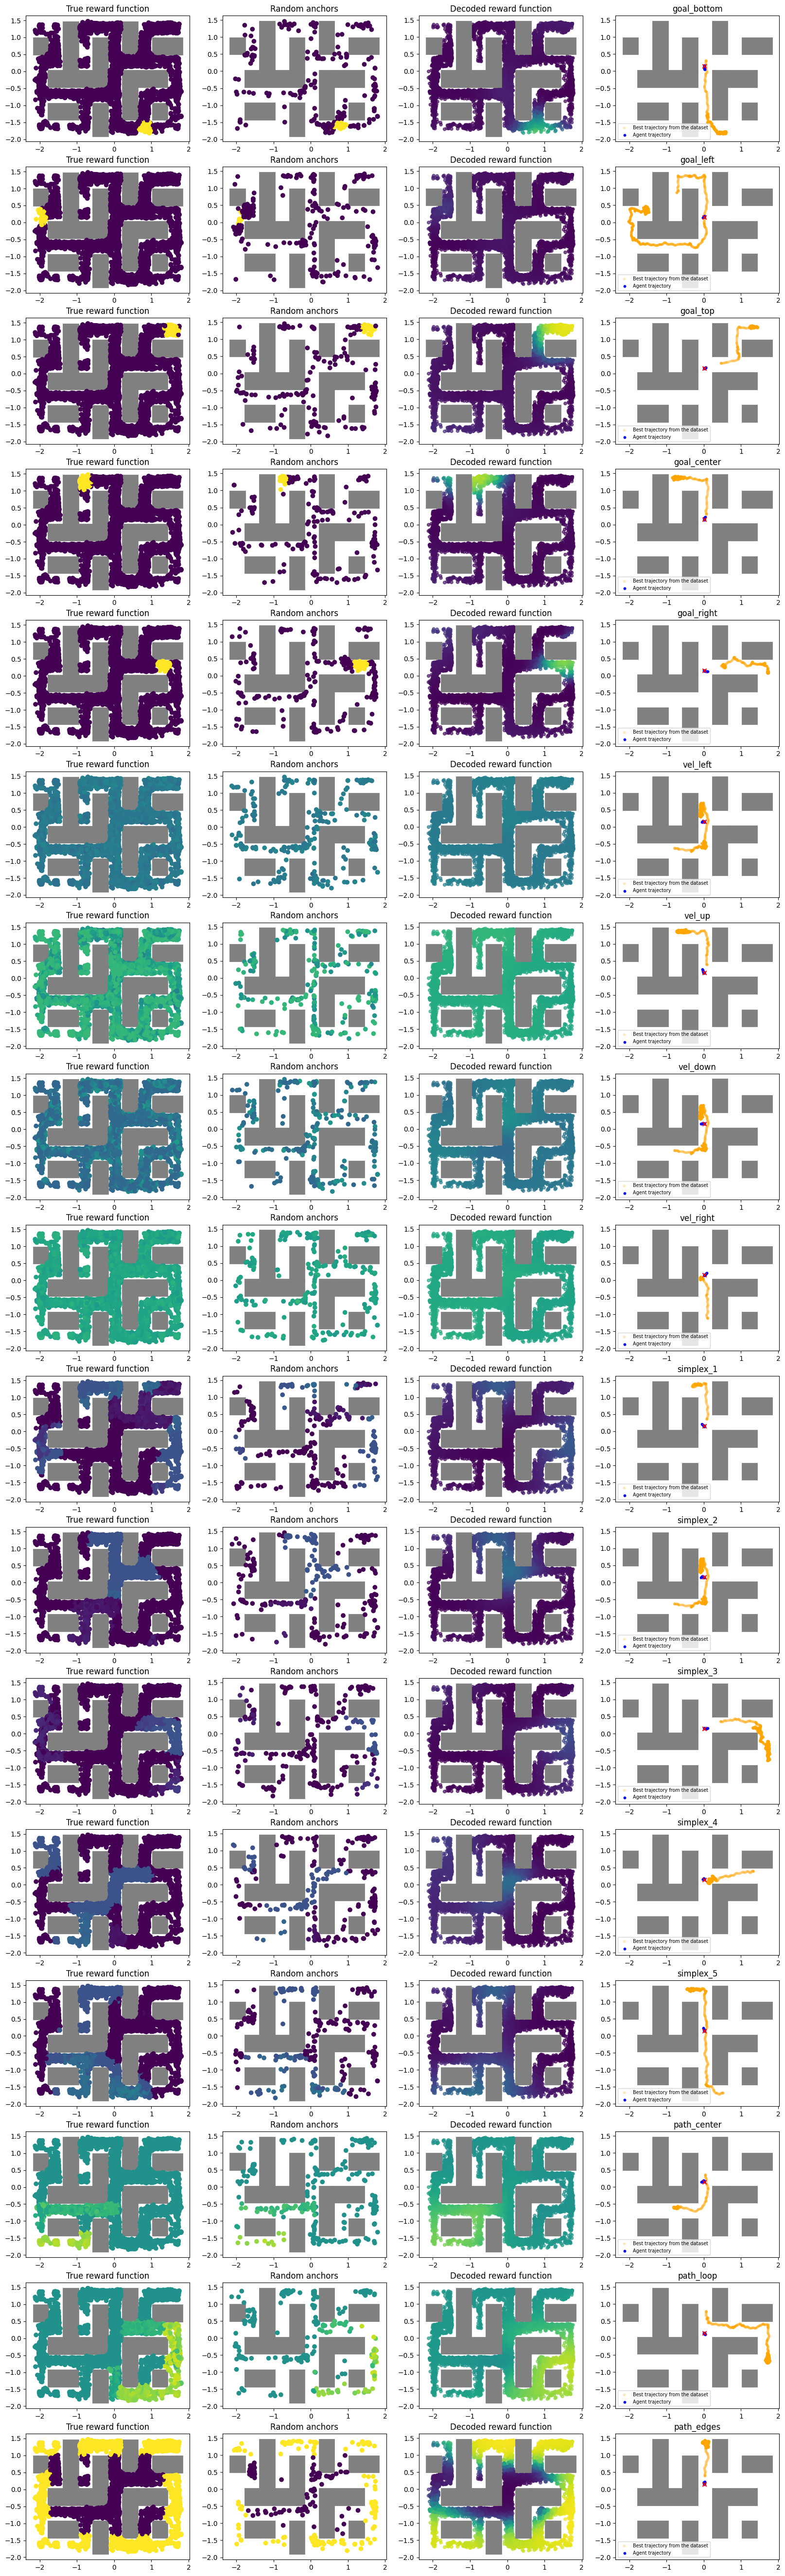

In [80]:
fig, all_axs = plt.subplots(len(benchmarks), 4, figsize=(20, len(benchmarks)*4))

reconstruction_losses = []

for benchmark_id in range(len(benchmarks)):
# for benchmark_id in range():
    
    axs = all_axs[benchmark_id]

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    print(benchmark_test_label)

    reward_z_list, start_states_list, produced_trajectories_list, best_trajectories_idx_list, best_trajectories_bench_idx_list, info = run_test(
        benchmark_id, num_evals=1, num_eval_anchors=256
    )

    # break



    _, _, eval_states, eval_states_rewards = visualize_eval(reward_z_list, reward_generator_2, axs=axs)


    axs[2].set_title('Decoded reward function')
    axs[3].set_title(f'{benchmark_test_label}')
    axs[1].set_title('Random anchors')
    axs[0].set_title('True reward function')
    
    add_largest_maze_walls(axs[2])
    add_largest_maze_walls(axs[3])
    add_largest_maze_walls(axs[1])
    add_largest_maze_walls(axs[0])

    # x = dataset_trajectories[get_best_trajectory_info['best_traj_idx'][0][0]]
    # x = dataset_trajectories[best_trajectories_idx_list[i]]
    # axs[i].scatter(x[:, 0], x[:, 1], c='orange', s=1, alpha=np.linspace(0.5, 1, 1001))

    for j in range(1):
        print(best_trajectories_idx_list[0][j])
        x = dataset_trajectories[best_trajectories_idx_list[0][j]]
        # axs[3].scatter(x[:, 0], x[:, 1], s=1, c=np.linspace(0.0, 1, 1001), cmap='hot')
        axs[3].scatter(x[:, 0], x[:, 1], s=10, c='orange', alpha=np.linspace(0.2, 1, 1001), label='Best trajectory from the dataset')
        
    axs[3].scatter(produced_trajectories_list[:, :, 0], produced_trajectories_list[:, :, 1], c='blue', s=10, label='Agent trajectory')
    axs[3].scatter(start_states_list[0, 0], start_states_list[0, 1], c='red', marker='x')
    axs[3].legend(loc='lower left', fontsize='x-small')



    # for j in range(1):
    #     # j = 5
    #     x = dataset_trajectories[best_trajectories_bench_idx_list[0][j]]
        
    #     # axs[3].scatter(x[:, 0], x[:, 1], s=1, c=np.linspace(0.0, 1, 1001), cmap='hot')
        
    #     rews = benchmark_reward_function(denormalize_dataset_coords(x), benchmark_param)
    #     axs[3].scatter(x[:, 0], x[:, 1], s=1, c=rews, vmin=-1, vmax=1)
    #     print(rews.max())
        
    #     # break
        
        

    anchors, anchors_rewards = info['anchors'], info['anchors_rewards']
    axs[1].scatter(anchors[..., 0].cpu(), anchors[..., 1].cpu(), c=anchors_rewards.cpu()[0], vmin=-1, vmax=1)    

    rews = benchmark_reward_function(denormalize_dataset_coords(dataset_trajectories[:, ::50]), benchmark_param)
    axs[0].scatter(dataset_trajectories[:, ::50, 0], dataset_trajectories[:, ::50, 1], c=rews, vmin=-1, vmax=1)
    

    # Reconstruction loss:
    true_rewards = benchmark_reward_function(denormalize_dataset_coords(eval_states), benchmark_param)
    reconstruction_loss = (eval_states_rewards - true_rewards).abs().mean().item()
    print(f'reconstruction_loss: {reconstruction_loss}')
    
    reconstruction_losses.append(reconstruction_loss)
    

    # break
    
print(f'mean reconstruction losses: {np.mean(reconstruction_losses)}')
print(f'std reconstruction losses: {np.std(reconstruction_losses)}')

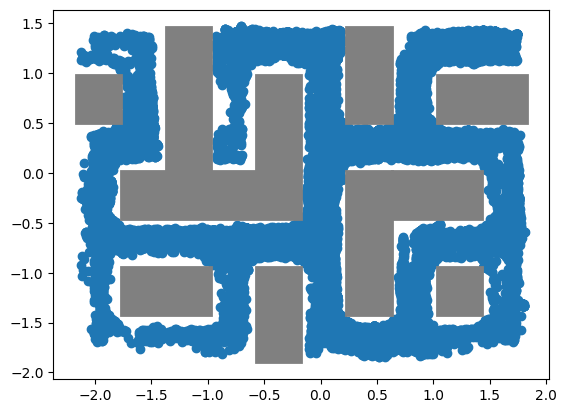

In [245]:
fig, ax = plt.subplots(1, 1)
# ax.scatter(anchors[..., 0].cpu(), anchors[..., 1].cpu(), c=anchors_rewards.cpu().tolist()[0])  
ax.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1])
# plt.scatter(anchors[..., 0].cpu(), anchors[..., 1].cpu(), c=[1, 1, 1, 1])  
add_largest_maze_walls(ax)

In [ ]:
dataset_trajectories_cuda

tensor([[[ 1.2303e+00,  6.3247e+00,  2.1268e-01,  3.7564e-02],
         [ 1.2437e+00,  6.3130e+00,  2.4194e-01, -3.2821e-01],
         [ 1.2576e+00,  6.2877e+00,  2.7734e-01, -1.9791e-01],
         ...,
         [ 1.4426e+00,  9.4687e+00,  1.2204e+00,  6.8140e-01],
         [ 1.4946e+00,  9.4734e+00,  9.7626e-01, -2.1347e-01],
         [ 1.5354e+00,  9.4496e+00,  1.1305e-01, -3.1318e-01]],

        [[ 9.2239e+00, -5.7943e+00, -7.5956e-02, -1.2466e-01],
         [ 9.2222e+00, -5.8165e+00, -1.5866e-02, -4.2993e-01],
         [ 9.2199e+00, -5.8513e+00, -6.7484e-02, -4.9189e-01],
         ...,
         [-1.7313e+00,  9.0642e+00,  2.1384e-04, -3.1812e-04],
         [-1.7313e+00,  9.0642e+00, -8.3662e-05, -4.0398e-05],
         [-1.7313e+00,  9.0641e+00,  2.1775e-04, -2.7533e-04]],

        [[-5.0412e+00, -2.6582e+00,  5.1715e-02,  4.6603e-02],
         [-5.0475e+00, -2.6570e+00, -2.4683e-01,  3.4014e-02],
         [-5.0622e+00, -2.6536e+00, -2.3666e-01,  3.3157e-02],
         ...,
         

## Reward Alignement method 2:

In [ ]:
class RewardFunctionEncoder(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.init_state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, init_state, states, rewards, pad_mask):  
        
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)
        
        init_state_emd = self.init_state_embed(init_state).unsqueeze(1)
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        # print(state_reward_emd.shape, init_state_emd.shape)
        
        x = torch.concat((init_state_emd, state_reward_emd), dim=1)
        pad_mask = torch.concat((pad_mask, pad_mask[:, [0]]), dim=1)
        
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [ ]:
re_batch_size = 128
num_random_samples = 200

In [ ]:
reward_encoder = RewardFunctionEncoder(obs_len=2, num_heads=2, num_layers=2).to(device)
reward_encoder_optimizer = torch.optim.Adam(reward_encoder.parameters(), lr=0.001)
reward_encoder_loss = []

In [104]:
for epoch in tqdm(range(10000)):
    
    start_states = dataset_trajectories[torch.randint(0, num_trajectories, (re_batch_size,)), 0, :2]
    
    # get a random reward function from the reward generator:
    with torch.no_grad():
        reward_w, info = reward_generator_2.get_z_from_random_anchors(re_batch_size, min_num_anchors=8, max_num_anchors=8, anchors_from_same_trajectory=False)
    
    
    # Get the representation of the reward function based on random states:
    buffer = dataset_trajectories[..., :2]
    trajectories_idx = torch.randint(0, buffer.shape[0], (num_random_samples*re_batch_size,)) # get random trajectory indicies
    states_idx = torch.randint(0, buffer.shape[1], (num_random_samples*re_batch_size,)) # get random state indicies
    random_states = buffer[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(re_batch_size, num_random_samples, 2).to(device)

    print(random_states.reshape(-1, 2).shape)
    print(reward_w.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128).shape)

    # Calculate the rewards of the selected random states using the trained Reward Function Generator:
    with torch.no_grad():
        random_states_rewards = reward_generator_2.get_reward(
            random_states.reshape(-1, 2),
            reward_w.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        )
    random_states_rewards = random_states_rewards.reshape(re_batch_size, num_random_samples)

    # Get the new representation of the reward function:
    pad_mask = torch.full((re_batch_size, num_random_samples), fill_value=False, device=device)
    new_reward_w, _ = reward_encoder.get_transformer_encoding(
        start_states.to(device),
        random_states, 
        random_states_rewards, 
        pad_mask=pad_mask
    )
    

    # Get the best trajectory:
    best_traj_w, _ = get_best_trajectory(start_states, reward_w)

    
    loss = (best_traj_w - new_reward_w).pow(2).sum(-1).mean()
    

    reward_encoder_optimizer.zero_grad()
    loss.backward()
    reward_encoder_optimizer.step()


    reward_encoder_loss.append(loss.item())
    
    break
    
    if epoch % 10 == 0:
        clear_output(True)
        plt.plot(reward_encoder_loss)
        # plt.ylim([0, 5])
        plt.show()
        
    break

  0%|          | 0/10000 [00:00<?, ?it/s]


NameError: name 're_batch_size' is not defined

In [ ]:
# torch.save(reward_encoder.state_dict(), 'models/offline_reward_encoder.pth')

In [ ]:
eval_re_batch_size = 1

reward_z_list = []
start_states_list = []
produced_trajectories_list = []
best_trajectories_idx_list = []


for num_eval in range(1):

    # Get a random starting position:
    env.reset()
    location = np.array(env.unwrapped._wrapped_env._get_reset_location())
    start_state = reset_to_location(env, location)
    start_state = normalize_dataset_coords(start_state)
    state = start_state
    
    tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()

    # Get a random reward function:
    with torch.no_grad():
        reward_z, info = reward_generator_2.get_z_from_random_anchors(eval_re_batch_size, min_num_anchors=8, max_num_anchors=8, anchors_from_same_trajectory=False)
    
    
    # Get the representation of the reward function based on random states:
    buffer = dataset_trajectories[..., :2]
    trajectories_idx = torch.randint(0, buffer.shape[0], (num_random_samples*eval_re_batch_size,)) # get random trajectory indicies
    states_idx = torch.randint(0, buffer.shape[1], (num_random_samples*eval_re_batch_size,)) # get random state indicies
    random_states = buffer[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(eval_re_batch_size, num_random_samples, 2).to(device)

    
    # Calculate the rewards of the selected random states using the trained Reward Function Generator:
    with torch.no_grad():
        random_states_rewards = reward_generator_2.get_reward(
            random_states.reshape(-1, 2),
            reward_z.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        )
    random_states_rewards = random_states_rewards.reshape(eval_re_batch_size, num_random_samples)

    # Get the new representation of the reward function:
    pad_mask = torch.full((eval_re_batch_size, num_random_samples), fill_value=False, device=device)
    trajectory_z, _ = reward_encoder.get_transformer_encoding(
        tensor_state[:, :2].to(device),
        random_states, 
        random_states_rewards, 
        pad_mask=pad_mask
    )
    
    # break

    # Get the best trajectory from the dataset:
    predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)



    # Run the agent conditioned on the predicted trajectory representation:

    produced_trajectory = []

    for step in tqdm(range(1000)):
        
        produced_trajectory.append(state)
        
        if step % 1 == 0:
            tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
            # predcited_best_w, get_best_trajectory_info = get_best_trajectory(tensor_state[:, :2].cpu(), reward_z)
            trajectory_z, _ = reward_encoder.get_transformer_encoding(tensor_state[:, :2].to(device), random_states, random_states_rewards, pad_mask=pad_mask)
        
        with torch.no_grad():
            tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
            # action = frenetwork.get_action_pred(predcited_best_w, tensor_state).cpu()
            action = frenetwork.get_action_pred(trajectory_z, tensor_state).cpu()
            action = np.array(action[0, 0])
            
        new_state, _, _, _ = env.step(action)
        
        state = normalize_dataset_coords(new_state)
        
        
        
    produced_trajectory = np.stack(produced_trajectory)
    
    ##############
    reward_z_list.append(reward_z)
    start_states_list.append(start_state)
    produced_trajectories_list.append(produced_trajectory)
    best_trajectories_idx_list.append(get_best_trajectory_info['best_traj_idx'][0][0].item())
    
reward_z_list = torch.concat(reward_z_list)
start_states_list = np.stack(start_states_list)
produced_trajectories_list = np.stack(produced_trajectories_list)
best_trajectories_idx_list = np.array(best_trajectories_idx_list)

Target Goal:  (32.861776651787885, 24.85402666143591)


100%|██████████| 1000/1000 [00:02<00:00, 461.81it/s]


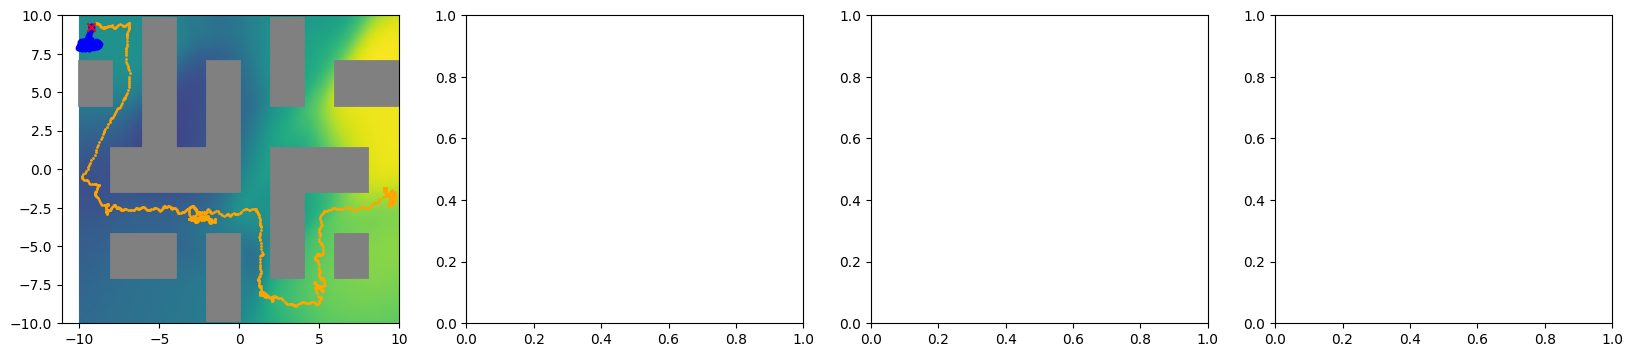

In [ ]:
fig, axs = visualize_rewards_and_trajectories(reward_z_list, reward_generator_2)

for i in range(reward_z_list.shape[0]):

    add_largest_maze_walls(axs[i])

    # x = dataset_trajectories[get_best_trajectory_info['best_traj_idx'][0][0]]
    x = dataset_trajectories[best_trajectories_idx_list[i]]
    axs[i].scatter(x[:, 0], x[:, 1], c='orange', s=1)

    axs[i].scatter(produced_trajectories_list[i, :, 0], produced_trajectories_list[i, :, 1], c='blue', s=10)
    axs[i].scatter(start_states_list[i, 0], start_states_list[i, 1], c='red', marker='x')



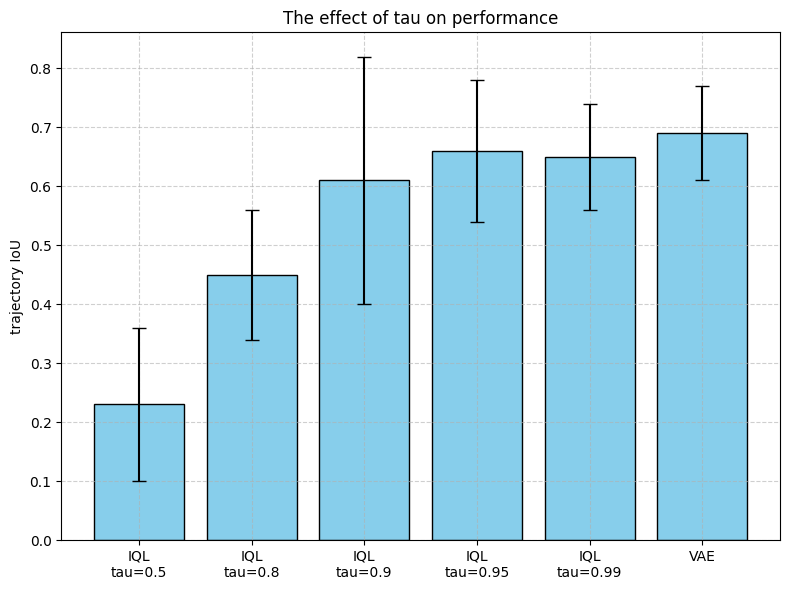

In [11]:
import matplotlib.pyplot as plt

# Data
x_labels = ['IQL\ntau=0.5', 'IQL\ntau=0.8', 'IQL\ntau=0.9', 'IQL\ntau=0.95', 'IQL\ntau=0.99', 'VAE']
values = [0.23, 0.45, 0.61, 0.66, 0.65, 0.69]
errors = [0.13, 0.11, 0.21, 0.12, 0.09, 0.08]

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(x_labels, values, yerr=errors, capsize=5, color='skyblue', edgecolor='black')

# Labeling
plt.ylabel('trajectory IoU')
plt.title('The effect of tau on performance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()
